# Optimize CN3S Model

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import pandas as pd
from sklearn.metrics import r2_score

from cn3s import CN3S, CN3SOptimizer, CN3SParams


## Load Data

In [2]:
BASIN = "BarraDosBugres"
STATION = 66010000
BASE_FOLDER = "/data/CN3S/basins/"

path = Path(BASE_FOLDER) / BASIN
assert path.exists(), f"Path {path} does not exist"

In [3]:
prec = pd.read_parquet(path / f"Daily_Prec_{STATION}.parquet")
prec.index = prec.index - pd.Timedelta(hours=12)  # + pd.Timedelta(days=4)
prec

,prec
time,
2000-01-01,4.962662
2000-01-02,4.615260
2000-01-03,3.587662
2000-01-04,0.001623
2000-01-05,0.389610
...,...
2026-06-11,0.000000
2026-06-12,0.006494
2026-06-13,0.000000


In [4]:
q = pd.read_parquet(path / f"Daily_Q_{STATION}.parquet")
q

,EstacaoCodigo,NivelConsistencia,Vazao
Data,,,
1966-01-02,66010000,2,104.26
1966-01-03,66010000,2,107.81
1966-01-04,66010000,2,108.53
1966-01-05,66010000,2,107.81
1966-01-06,66010000,2,99.31
...,...,...,...
2025-12-27,66010000,1,125.14
2025-12-28,66010000,1,115.80
2025-12-29,66010000,1,112.90


## Manual tests

BASELINE PARAMS

CN3SParams(area=9642, r0=822.4829852697771, cn_i=9.379436702350787, alfa=36.12794597556747, beta=3.01111976368853, k0=7.007933208834954, k1=10.294516538326205, k2=0.023382291010210388)


In [ ]:
sliced_prec = prec.iloc[-2000:-1000]

In [ ]:
AREA = 9642  # km² — update if using a different basin
params = CN3SParams(
    area=AREA,
    r0=822,
    cn_i=9.38,
    alfa=36.13,
    beta=3,
    k0=7,
    k1=10.3,
    k2=0.0234,
    act=5,
    warmup_steps=5,
)


model = CN3S(params)
model.params

CN3SParams(area=9642, r0=822, cn_i=9.38, alfa=36.13, beta=3, k0=7, k1=10.3, k2=0.0234, act=5, warmup_steps=5)

In [ ]:
model.run(sliced_prec["prec"])

Running CN3S model:   0%|          | 0/994 [00:00<?, ?step/s]

In [ ]:
model.evaluate(q["Vazao"])

0.7295685452501368

In [ ]:
model.results

,prec,past_prec,vj,cnv,s,q_up,r1,q_low,r,q_mm,q_m3s,obs_q_m3s
time,,,,,,,,,,,,
2021-01-01,10.49513,"[18.154220581054688, 0.030844155699014664, 5.5...",5.0,71.465824,101.41464,0.0,930.099835,21.764336,908.335499,21.764336,80.961315,56.35
2021-01-02,4.163149,"[10.495129585266113, 18.154220581054688, 0.030...",5.0,71.465824,101.41464,0.0,951.215937,22.258453,928.957484,22.258453,82.799384,58.57
2021-01-03,8.571428,"[4.163149356842041, 10.495129585266113, 18.154...",5.0,71.465824,101.41464,0.0,1017.243196,23.803491,993.439705,23.803491,88.546782,58.57
2021-01-04,0.106331,"[8.571428298950195, 4.163149356842041, 10.4951...",5.0,71.465824,101.41464,0.0,994.534916,23.272117,971.262799,23.272117,86.570121,58.57
2021-01-05,8.795455,"[0.10633116960525513, 8.571428298950195, 4.163...",5.0,71.465824,101.41464,0.0,1061.855985,24.84743,1037.008555,24.84743,92.430139,35.23
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-20,0.00487,"[12.53246784210205, 0.0, 0.0]",5.0,71.465824,101.41464,0.0,272.847069,6.384621,266.462448,6.384621,23.750201,22.73
2023-09-21,0.0,"[0.004870129749178886, 12.53246784210205, 0.0]",5.0,71.465824,101.41464,0.0,266.462448,6.235221,260.227227,6.235221,23.194446,21.23
2023-09-22,0.137987,"[0.0, 0.004870129749178886, 12.53246784210205]",5.0,71.465824,101.41464,0.0,261.648493,6.122575,255.525918,6.122575,22.775411,21.23


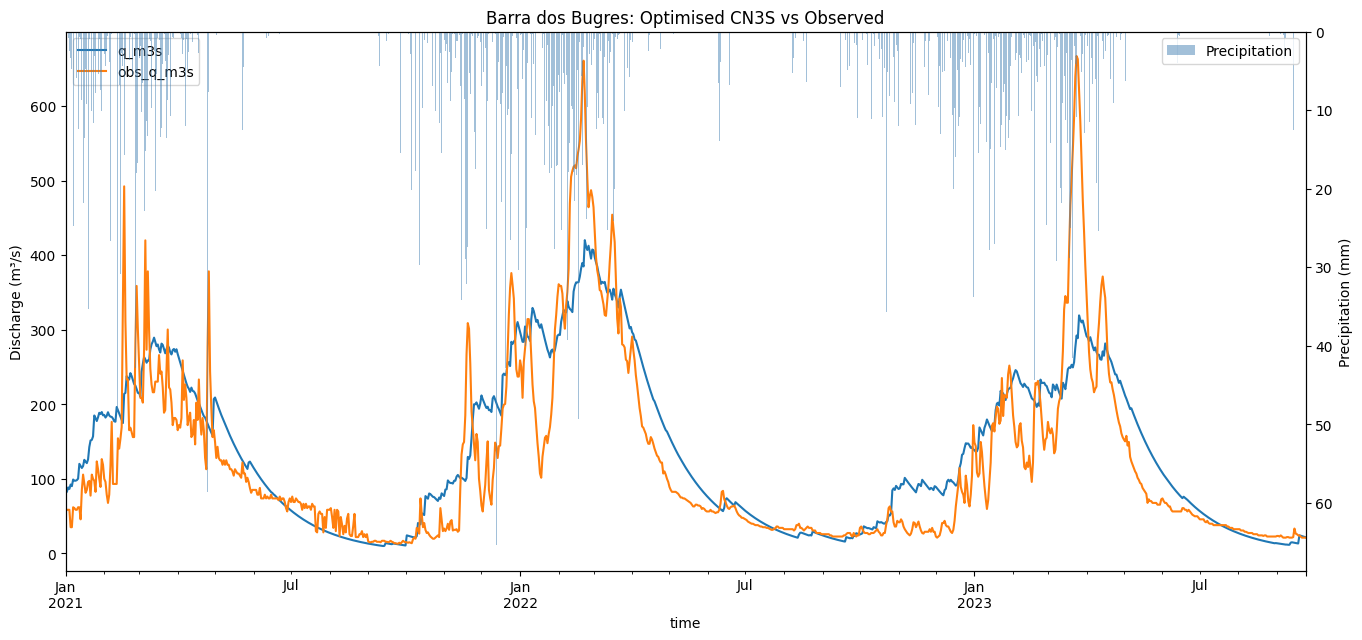

In [ ]:
results = model.results.copy()
ax = results.plot(
    y=["q_m3s", "obs_q_m3s"], figsize=(16, 7), title="Barra dos Bugres: Optimised CN3S vs Observed"
)
ax.legend(loc="upper left")
ax.set_ylabel("Discharge (m³/s)")

shifted_prec = sliced_prec.shift(0)
ax2 = ax.twinx()
ax2.bar(
    shifted_prec.index, shifted_prec["prec"], color="steelblue", alpha=0.5, label="Precipitation"
)
ax2.invert_yaxis()
ax2.set_ylabel("Precipitation (mm)")
ax2.legend(loc="upper right")

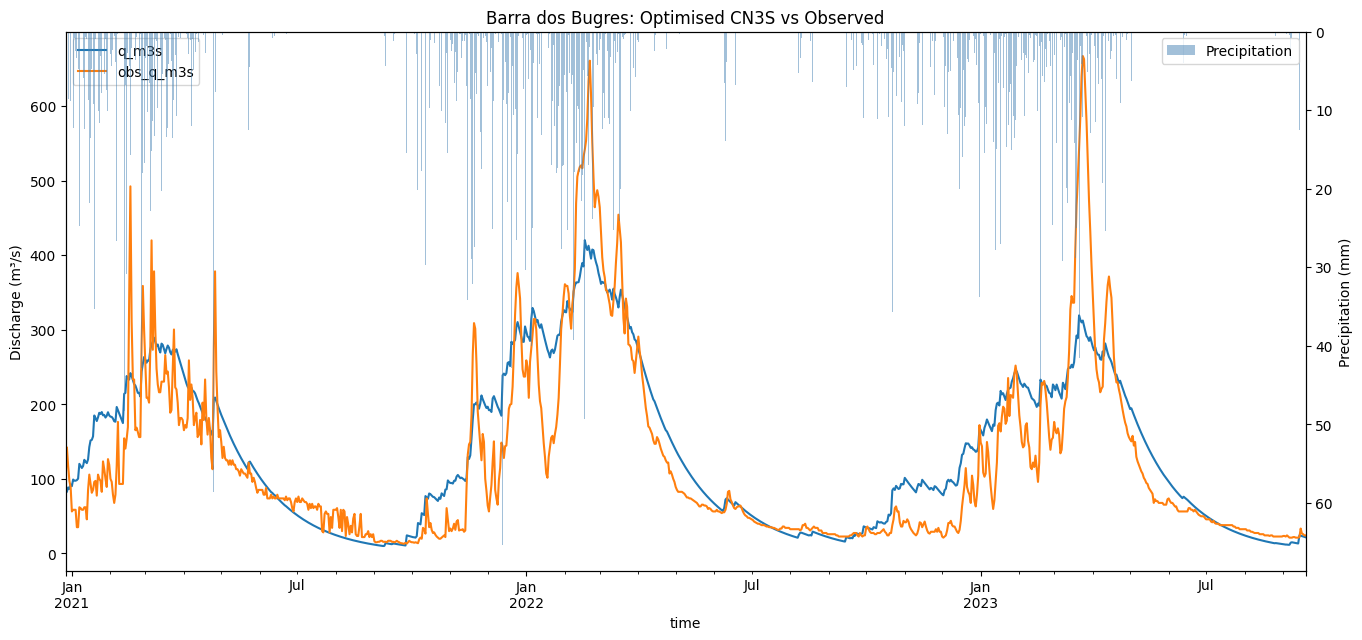

In [ ]:
results = model.results.copy()
ax = results.plot(
    y=["q_m3s", "obs_q_m3s"], figsize=(16, 7), title="Barra dos Bugres: Optimised CN3S vs Observed"
)
ax.legend(loc="upper left")
ax.set_ylabel("Discharge (m³/s)")

shifted_prec = sliced_prec.shift(0)
ax2 = ax.twinx()
ax2.bar(
    shifted_prec.index, shifted_prec["prec"], color="steelblue", alpha=0.5, label="Precipitation"
)
ax2.invert_yaxis()
ax2.set_ylabel("Precipitation (mm)")
ax2.legend(loc="upper right")

## Run Optimizer

In [5]:
sliced_prec = prec.iloc[-4000:-1000]

AREA = 9642  # km² — update if using a different basin

model = CN3S(CN3SParams(area=AREA, warmup_steps=5))

optim = CN3SOptimizer(
    prec=sliced_prec["prec"],
    observed_q=q["Vazao"],
    model=model,
    train_ratio=0.8,
    weights_power=2,
    max_act=30,
)

print(f"Aligned record: {len(optim.aligned)} time steps")
print(f"Train: {optim.train_idx} | Test: {len(optim.aligned) - optim.train_idx}")

Aligned record: 3000 time steps
Train: 2400 | Test: 600


In [6]:
# Interrupt at any time — optim.model will hold the best parameters seen so far.
optim.optimize(maxiter=1000, tol=1e-4, disp=False, workers=-1)

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


1 - Train NSE: -0.1086 | Test NSE: 0.0822 <-- new best NSE! (CN3SParams(area=9642, r0=400.85489700109184, cn_i=13.729838355420185, alfa=8.778826268621863, beta=17.791671120099473, k0=17.159679527591724, k1=13.753106599722598, k2=0.06389072998937295, act=30, warmup_steps=5))
2 - Train NSE: -0.1086 | Test NSE: 0.0822 (CN3SParams(area=9642, r0=400.85489700109184, cn_i=13.729838355420185, alfa=8.778826268621863, beta=17.791671120099473, k0=17.159679527591724, k1=13.753106599722598, k2=0.06389072998937295, act=30, warmup_steps=5))
3 - Train NSE: -0.1086 | Test NSE: 0.0822 (CN3SParams(area=9642, r0=400.85489700109184, cn_i=13.729838355420185, alfa=8.778826268621863, beta=17.791671120099473, k0=17.159679527591724, k1=13.753106599722598, k2=0.06389072998937295, act=30, warmup_steps=5))
4 - Train NSE: -0.0299 | Test NSE: 0.1673 <-- new best NSE! (CN3SParams(area=9642, r0=815.2893663287186, cn_i=24.187820918262446, alfa=5.574927539838875, beta=8.643852294728045, k0=8.73359272819742, k1=13.387755

Process ForkPoolWorker-3:
Process ForkPoolWorker-5:
Process ForkPoolWorker-1:
Process ForkPoolWorker-6:
Process ForkPoolWorker-2:
Process ForkPoolWorker-4:



Optimization interrupted — best model so far is in `optim.model`.


In [21]:
optim.model.params = optim.params_dict[116]

In [22]:
df = optim._run_model(optim._best_params_vec)

In [25]:
optim._nse(df, use_weights=False, train=False)

0.8293003889885351

In [27]:
optim.params_dict[116].as_list()

[920.5475055655855,
 36.08908328505768,
 75.68155343449753,
 10.81640236830544,
 11.39250693974385,
 11.790311051310702,
 0.027220613635929758,
 1.0]

In [8]:
optim._objective(optim.params_dict[15].as_list())

0.6528268534290358

In [9]:
model.evaluate(q["Vazao"])

Aligned 2995 time steps between model results and observations.
From 2015-07-10 00:00:00 to 2023-09-20 00:00:00.


0.5588427334801555

## Evaluate Results

In [12]:
# Split index (adjusted for 3-month warm-up)
split = optim.train_idx - optim._warmup_steps

In [10]:
model.params = optim.params_dict[17]
model.run(sliced_prec["prec"])
model.evaluate(q["Vazao"])
results = model.results.copy()

Running CN3S model:   0%|          | 0/2994 [00:00<?, ?step/s]

Aligned 2995 time steps between model results and observations.
From 2015-07-10 00:00:00 to 2023-09-20 00:00:00.


In [13]:
train_nse = r2_score(results.iloc[:split]["obs_q_m3s"], results.iloc[:split]["q_m3s"])
test_nse = r2_score(results.iloc[split:]["obs_q_m3s"], results.iloc[split:]["q_m3s"])

print(f"Train NSE: {train_nse:.4f}")
print(f"Test  NSE: {test_nse:.4f}")

Train NSE: 0.4747
Test  NSE: 0.7794


In [14]:
fig = optim.model.plot(
    split=split,
    q_headroom=1.5,
    prec_headroom=3,
    title="Barra dos Bugres: Optimised CN3S vs Observed",
)
fig

In [15]:
model.params = optim.params_dict[79]
model.run(sliced_prec["prec"])
model.evaluate(q["Vazao"])
results = model.results.copy()

fig = optim.model.plot(
    split=split,
    q_headroom=1.5,
    prec_headroom=3,
    title="Barra dos Bugres: Optimised CN3S vs Observed",
)
fig

Running CN3S model:   0%|          | 0/2994 [00:00<?, ?step/s]

Aligned 2995 time steps between model results and observations.
From 2015-07-10 00:00:00 to 2023-09-20 00:00:00.


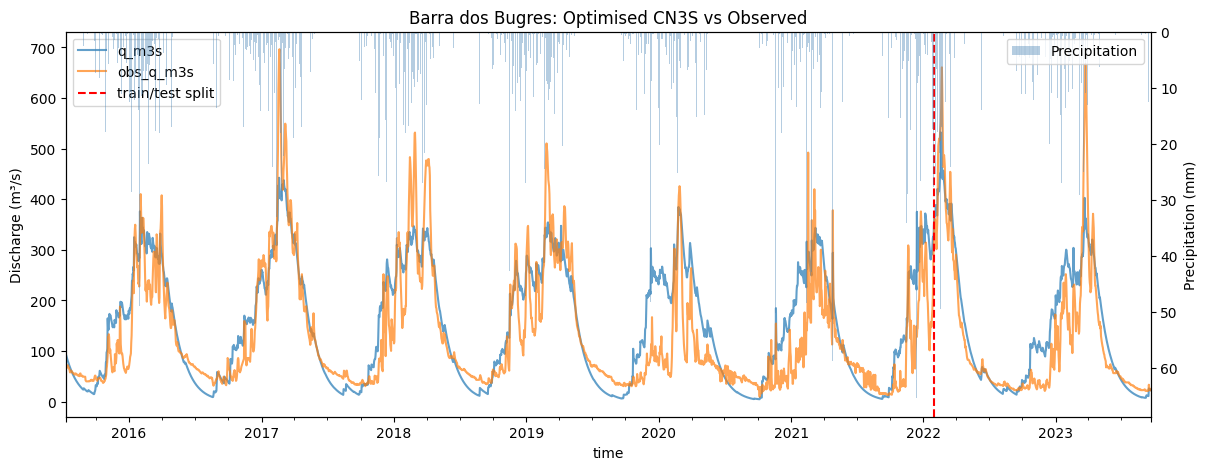

In [27]:
ax = results.plot(
    y=["q_m3s", "obs_q_m3s"],
    figsize=(14, 5),
    title="Barra dos Bugres: Optimised CN3S vs Observed",
    alpha=0.7,
)
ax.axvline(results.index[split], color="red", linestyle="--", label="train/test split")
ax.legend(loc="upper left")
ax.set_ylabel("Discharge (m³/s)")

shifted_prec = sliced_prec.shift(0)
ax2 = ax.twinx()
ax2.bar(
    shifted_prec.index, shifted_prec["prec"], color="steelblue", alpha=0.4, label="Precipitation"
)
ax2.invert_yaxis()
ax2.set_ylabel("Precipitation (mm)")
ax2.legend(loc="upper right")


In [36]:
model.params

CN3SParams(area=9642, r0=573.6598651487596, cn_i=27.79349411859151, alfa=0.6661078609288182, beta=19.937421704235888, k0=16.06807339242173, k1=11.458679913464879, k2=0.032049538658250665, act=3, warmup_steps=5)

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

# Discharge traces (primary y-axis)
fig.add_trace(
    go.Scatter(
        x=results.index,
        y=results["q_m3s"],
        name="q_m3s",
        line={"color": "steelblue"},
        opacity=0.7,
    ),
)
fig.add_trace(
    go.Scatter(
        x=results.index,
        y=results["obs_q_m3s"],
        name="obs_q_m3s",
        line={"color": "darkorange"},
        opacity=0.7,
    ),
)

# Train/test split vertical line
split_date = results.index[split]
fig.add_shape(
    type="line",
    x0=split_date,
    x1=split_date,
    y0=0,
    y1=1,
    yref="paper",
    line={"color": "red", "dash": "dash"},
)
fig.add_annotation(
    x=split_date,
    y=1,
    yref="paper",
    text="train/test split",
    showarrow=False,
    xanchor="left",
    yanchor="top",
    font={"color": "red"},
)

# Axis headroom to reduce visual overlap between lines and bars
q_max = float(results[["q_m3s", "obs_q_m3s"]].max().max())
prec_max = float(results["prec"].max())
q_upper = q_max * 1.2
prec_upper = prec_max * 1.5

# Precipitation bars (secondary y-axis, inverted)
fig.add_trace(
    go.Bar(
        x=results.index,
        y=results["prec"],
        name="Precipitation",
        marker_color="steelblue",
        opacity=0.9,
        yaxis="y2",
    )
)

_axis_style = {"showline": True, "linewidth": 1, "linecolor": "black", "mirror": True}

fig.update_layout(
    title="Barra dos Bugres: Optimised CN3S vs Observed",
    xaxis={"title": "Date", **_axis_style},
    yaxis={"title": "Discharge (m³/s)", "range": [0, q_upper], **_axis_style},
    yaxis2={
        "title": "Precipitation (mm)",
        "overlaying": "y",
        "side": "right",
        "range": [prec_upper, 0],
        **_axis_style,
    },
    legend={"x": 0.01, "y": 0.99},
    height=500,
    width=1000,
    plot_bgcolor="white",
)

fig.show()


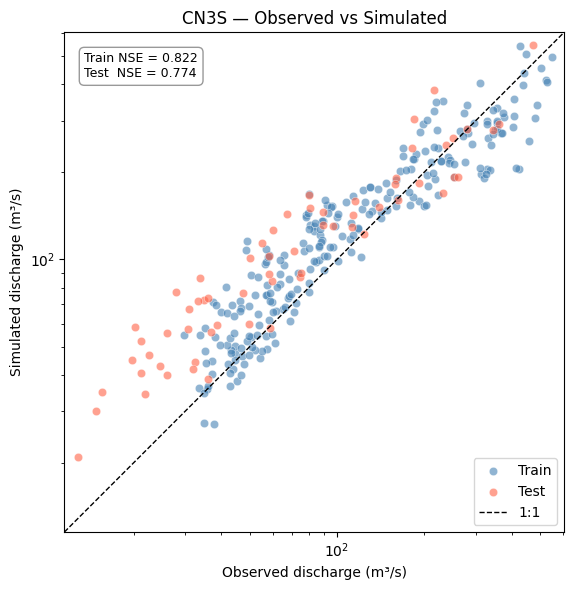

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 6))

# Train and test points with distinct colours
ax.scatter(
    results.iloc[:split]["observed_q"],
    results.iloc[:split]["q_m3s"],
    alpha=0.6,
    label="Train",
    color="steelblue",
    edgecolors="white",
    linewidths=0.4,
)
ax.scatter(
    results.iloc[split:]["observed_q"],
    results.iloc[split:]["q_m3s"],
    alpha=0.6,
    label="Test",
    color="tomato",
    edgecolors="white",
    linewidths=0.4,
)

ax.set_xscale("log")
ax.set_yscale("log")

# 1:1 line spanning the full data range (log-safe: use positive values only)
all_vals = pd.concat([results["observed_q"], results["q_m3s"]])
all_vals = all_vals[all_vals > 0]
lims = [all_vals.min() * 0.9, all_vals.max() * 1.1]
ax.plot(lims, lims, "k--", linewidth=1, label="1:1")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")

ax.set_xlabel("Observed discharge (m³/s)")
ax.set_ylabel("Simulated discharge (m³/s)")
ax.set_title("CN3S — Observed vs Simulated")

# NSE annotation box (top-left)
textstr = f"Train NSE = {train_nse:.3f}\nTest  NSE = {test_nse:.3f}"
ax.text(
    0.04,
    0.96,
    textstr,
    transform=ax.transAxes,
    verticalalignment="top",
    bbox={"boxstyle": "round,pad=0.4", "facecolor": "white", "edgecolor": "grey", "alpha": 0.8},
    fontsize=9,
)

ax.legend(loc="lower right")
plt.tight_layout()

In [19]:
# Calibrated parameters
optim.model.params

CN3SParams(area=9642, r0=98.95846565107985, cn_i=9.048392320346426, alfa=0.19965320663305813, beta=0.003796888013248299, k0=0.5528689602670063, k1=0.3312926383090628, k2=0.3332066544700027)